#  Decision Tree Assignment

## Section 1: Theoretical Questions 

## Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

#### Answer :

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It predicts the output by splitting the data into smaller groups based on different conditions.

**Structure of a Decision Tree:**

- **Root Node:** The first node that represents the entire dataset and makes the initial decision.
- **Decision Nodes:** Internal nodes where the data is split based on feature values.
- **Leaf Nodes:** The final nodes that represent the predicted outcome or class.

**Real-life Example:**

Suppose a bank wants to decide whether to approve a loan.

- Root Node: Check the applicant's credit score.
- Decision Node: If the credit score is high, check the applicant's income.
- Leaf Node: Approve or Reject the loan.

A Decision Tree makes decisions step by step until it reaches the final prediction.

## Q2. Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-learn and why?

#### Answer :

Gini Impurity and Entropy are measures used to determine the best feature for splitting data in a Decision Tree.

| Gini Impurity | Entropy |
|--------------|---------|
| Measures the probability of incorrect classification. | Measures the amount of disorder or uncertainty in the data. |
| Simpler and computationally faster. | Computationally more expensive because it uses logarithms. |
| Values range from 0 to 0.5 (for binary classification). | Values range from 0 to 1 (for binary classification). |
| Used to create pure child nodes efficiently. | Focuses on maximizing information gain. |

**Default Criterion in Scikit-learn:**

Scikit-learn uses **Gini Impurity** as the default criterion because it is computationally faster and generally provides performance similar to Entropy while requiring less computation.

## Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

#### Answer :

Overfitting occurs when a Decision Tree learns the training data too closely, including noise and unnecessary details. As a result, it performs very well on the training data but poorly on new or unseen data.

We can detect overfitting by comparing the training and testing accuracy.

- If both training and testing accuracy are high and similar, the model is well-fitted.
- If training accuracy is very high but testing accuracy is much lower, the model is overfitting.
- If both training and testing accuracy are low, the model is underfitting.

Comparing training and testing accuracy helps determine whether the model generalizes well to new data.

## Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

#### Answer :

Pruning is the process of reducing the size of a Decision Tree by removing unnecessary branches. It helps reduce overfitting and improves the model's ability to generalize to new data.

**Pre-pruning:**

- Stops the tree from growing beyond a certain point.
- Uses conditions such as `max_depth`, `min_samples_split`, or `min_samples_leaf`.
- Simpler and faster because it prevents unnecessary tree growth.

**Post-pruning:**

- Builds the complete tree first and then removes branches that contribute little to prediction accuracy.
- Produces a more optimized tree but requires additional computation.

**Difference:**

| Pre-pruning | Post-pruning |
|-------------|--------------|
| Stops tree growth early. | Removes branches after the tree is fully grown. |
| Faster and simpler. | More computationally intensive. |
| May stop the tree too early. | Usually produces a more optimized model. |

## Q5. What is Feature Importance? How can it help businesses in decision-making?

#### Answer :

Feature Importance measures how much each feature contributes to the predictions made by a Decision Tree model. Features with higher importance have a greater influence on the model's decisions.

Feature importance helps businesses by:

- Identifying the most influential factors affecting predictions.
- Improving decision-making based on important variables.
- Reducing unnecessary features to simplify the model.
- Saving time and computational resources.
- Helping managers focus on the factors that have the greatest impact on business outcomes.

For example, in a loan approval system, if **credit score** and **income** have the highest feature importance, the bank can focus more on these factors while evaluating loan applications.

## Q6. Data Understanding

### Question

- Load the dataset.
- Display the first 5 rows.
- Check:
  - Shape
  - Data types
  - Column names
- Interpret: What types of variables are present?

#### Answer :

The first step in any Machine Learning project is to understand the dataset. This includes examining the first few records, checking the number of rows and columns, identifying the data types of each feature, and understanding the variables available for analysis.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

%matplotlib inline

In [2]:
# Load Dataset

df = pd.read_csv("bank.csv")

In [3]:
# Display first five rows

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
# Shape

print("Dataset Shape:", df.shape)

Dataset Shape: (11162, 17)


In [6]:
# Data Types

df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [7]:
# Column Names

print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


### Interpretation

The dataset contains both **numerical** and **categorical** variables.

- Numerical variables include features such as **age, balance, duration, campaign, pdays, previous,** and **day**.
- Categorical variables include **job, marital, education, default, housing, loan, contact, month, poutcome,** and **deposit**.

The target variable is **deposit**, which indicates whether a customer subscribed to a term deposit ("yes" or "no").

## Q7. Data Cleaning

### Question

- Check for missing values.
- Handle missing values (if any).
- Check for duplicates.
- Interpret: Is the dataset clean? What issues did you find?

#### Answer :

Data cleaning ensures that the dataset is suitable for model building. Missing values and duplicate records are identified and handled before further analysis.

In [8]:
# Missing Values

df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [9]:
# Duplicate Records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Interpretation

The dataset was checked for missing values and duplicate records.

- No missing values are found, so no treatment is required.
- NO Duplicate records present.

The cleaned dataset is now ready for preprocessing.

## Q8. Data Preprocessing

### Question

- Convert categorical variables into numerical.
- Mention which encoding method you used.
- Interpret: Why is encoding necessary for Decision Trees?

#### Answer :

Machine Learning algorithms require numerical input. Therefore, all categorical variables are converted into numerical values using **Label Encoding**.

In [11]:
# Label Encoding

label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


### Interpretation

**Encoding Method Used:** Label Encoding

Encoding converts categorical values into numerical values so that the Decision Tree algorithm can process them. Without encoding, the model cannot interpret text-based categorical variables.

## Q9. Feature Selection & Splitting

### Question

- Separate:
  - Features (X)
  - Target (y)
- Perform train-test split (80-20).
- Interpret: Why is train-test split important?

#### Answer :

The independent variables (features) are used to predict the target variable. The dataset is divided into training and testing sets so that the model can be evaluated on unseen data.

In [12]:
# Features and Target

X = df.drop('deposit', axis=1)

y = df['deposit']

In [13]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8929, 16)
Testing Data: (2233, 16)


### Interpretation

The training dataset is used to train the Decision Tree model, while the testing dataset is used to evaluate its performance on unseen data.

Using separate training and testing datasets helps assess how well the model generalizes to new data.

## Q10. Model Building

### Question

- Train a Decision Tree Classifier.
- Use:
  - criterion = 'gini'
  - max_depth = 5
- Interpret: What does max_depth control?

#### Answer :

A Decision Tree Classifier is trained using the Gini Impurity criterion. The maximum depth of the tree is limited to 5 to reduce the risk of overfitting.

In [14]:
# Build Decision Tree Model

dt_model = DecisionTreeClassifier(

    criterion='gini',
    max_depth=5,
    random_state=42

)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
# Predictions

y_pred = dt_model.predict(X_test)

In [16]:
# Actual vs Predicted

comparison = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

comparison.head(10)

,Actual,Predicted
5527,0,1
4541,1,1
1964,1,1
5007,1,1
8928,0,0
8936,0,1
6141,0,0
8786,0,0
8697,0,1
8582,0,1


###  max_depth control -

The parameter **max_depth = 5** limits the maximum depth of the Decision Tree to five levels.

Limiting the depth helps reduce overfitting by preventing the tree from becoming too complex. A smaller depth generally improves the model's ability to generalize to unseen data, while a larger depth may increase training accuracy but can reduce performance on new data.

## Q11. Model Evaluation

### Question

Perform:

- Accuracy Score
- Confusion Matrix
- Classification Report

Interpret (MUST):

- Is the model performing well?
- Explain Precision and Recall.
- Any class imbalance issue?

#### Answer :

After training the Decision Tree model, its performance is evaluated using different classification metrics. These metrics help determine how accurately the model predicts whether a customer will subscribe to a term deposit.

In [18]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8051948051948052


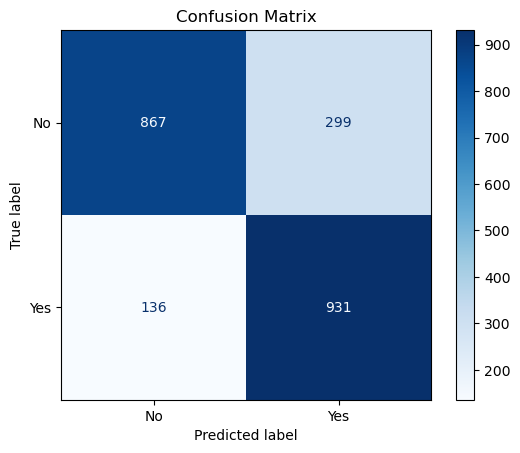

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [20]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



### Interpretation

- **Accuracy** represents the proportion of correctly classified loan applications.
- **Precision** indicates how many customers predicted as "Yes" actually subscribed to the term deposit.
- **Recall** indicates how many actual "Yes" customers were correctly identified by the model.
- The confusion matrix helps visualize correct and incorrect predictions.

If the Precision and Recall values for both classes are reasonably high and similar, the model is performing well.

Any class imbalance can be identified by comparing the support values in the classification report.

## Q12. Overfitting Check

### Question

Calculate:

- Training Accuracy
- Testing Accuracy

Interpret:

Is the model overfitting or underfitting?

#### Answer :

Comparing training and testing accuracy helps determine whether the Decision Tree generalizes well to unseen data.

In [21]:
# Training Accuracy

train_pred = dt_model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy

test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_accuracy)

print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.8149848807257252
Testing Accuracy  : 0.8051948051948052


### Interpretation

The training accuracy is **81.50%**, while the testing accuracy is **80.52%**.

The difference between the two accuracies is very small (less than 1%), which indicates that the model generalizes well to unseen data.

Since the training accuracy is only slightly higher than the testing accuracy, there is **no evidence of overfitting or underfitting**. The Decision Tree is considered **well-fitted** for this dataset.

## Q13. Pruning Experiment

### Question

Train another model with:

- max_depth = 3
- min_samples_split = 20

Interpret:

- Compare performance with the previous model.
- Which model is better and why?

#### Answer :

Pruning reduces the complexity of the Decision Tree and helps improve its ability to generalize by preventing overfitting.

In [22]:
# Pruned Decision Tree

pruned_model = DecisionTreeClassifier(

    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42

)

pruned_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
# Predictions

pruned_pred = pruned_model.predict(X_test)

pruned_accuracy = accuracy_score(y_test, pruned_pred)

print("Accuracy of Original Model :", test_accuracy)

print("Accuracy of Pruned Model   :", pruned_accuracy)

Accuracy of Original Model : 0.8051948051948052
Accuracy of Pruned Model   : 0.7653381101656964


### Interpretation

The original Decision Tree model achieved a testing accuracy of **80.52%**, whereas the pruned model achieved an accuracy of **76.53%**.

The original model performs better than the pruned model on the testing dataset.

Although pruning simplifies the Decision Tree and helps reduce overfitting, in this case it removed useful decision rules, resulting in lower prediction accuracy.

Therefore, the **original Decision Tree model (max_depth = 5)** is preferred because it provides better predictive performance while still maintaining good generalization.

## Q14. Feature Importance

### Question

- Extract the top 5 important features.
- Plot the feature importance graph.

Interpret:

Which features influence prediction the most?

#### Answer :

Feature importance indicates how much each feature contributes to the Decision Tree's predictions.

In [24]:
# Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": dt_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",
    ascending=False

)

importance.head()

,Feature,Importance
11,duration,0.595239
8,contact,0.121729
13,pdays,0.084299
6,housing,0.067469
10,month,0.054023


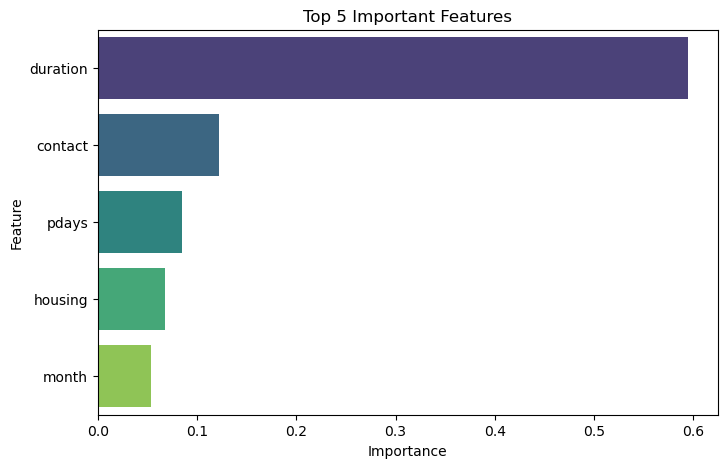

In [26]:
# Plot Top 5 Features
top5 = importance.head(5)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top5,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 5 Important Features")

plt.show()


### Interpretation

The feature importance analysis shows that **duration** is the most influential feature in predicting whether a customer will subscribe to a term deposit, with an importance score of **0.595**.

The top five important features are:

1. Duration (0.595)
2. Contact (0.122)
3. Pdays (0.084)
4. Housing (0.067)
5. Month (0.054)

This indicates that the duration of the last customer interaction has the greatest impact on the model's prediction, followed by the contact method, the number of days since the previous contact, housing loan status, and the month in which the customer was contacted.

## Q15. Business Insights

### Question

Based on your model, answer:

- Which type of customers are more likely to say "Yes"?
- What strategy should a bank use?

#### Answer :

According to the Decision Tree model, customers are more likely to subscribe to a term deposit when they have characteristics associated with the most important features identified by the model.

The most influential factor is the **duration of the customer interaction**, followed by the **contact method**, **previous contact history (pdays)**, **housing loan status**, and the **month** of contact.

### Business Recommendations

- Increase the quality and effectiveness of customer conversations, as longer interactions are strongly associated with successful subscriptions.
- Use the most effective contact methods identified by the model.
- Prioritize customers with favorable previous contact history.
- Plan marketing campaigns during the months that show better customer responses.
- Use the Decision Tree model to identify high-potential customers and target them with personalized marketing campaigns.

These strategies can improve marketing efficiency and increase the likelihood of customer subscriptions.

# Conclusion

A Decision Tree Classifier was successfully developed to predict whether customers would subscribe to a term deposit.

The dataset was explored, cleaned, preprocessed, and used to train a Decision Tree model with the Gini criterion and a maximum depth of 5. The model achieved a **testing accuracy of 80.52%**, indicating good predictive performance.

The confusion matrix and classification report showed balanced Precision and Recall values, suggesting that the model performs well for both classes without significant class imbalance. The comparison between training accuracy (81.50%) and testing accuracy (80.52%) indicates that the model is well-fitted and does not suffer from overfitting.

Feature importance analysis revealed that **duration** is the most influential factor affecting customer subscription decisions, followed by **contact**, **pdays**, **housing**, and **month**.

Overall, the Decision Tree model provides valuable insights that can help banks identify potential customers and improve the effectiveness of their marketing campaigns.